### 00. imports

In [224]:
from statistics import median
import regex
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

### 01. load and check the dataset

In [129]:
import kagglehub

files = kagglehub.dataset_download(
    "dolbokostya/test-dataset"
)

print(files)

/home/breezy/.cache/kagglehub/datasets/dolbokostya/test-dataset/versions/2


In [130]:
! cp -r ./data/ /home/breezy/.cache/kagglehub/datasets/dolbokostya/test-dataset/versions/2

In [216]:
df_raw = pd.read_csv("./data/2.5m-reviews-dataset.csv")
df_raw

,Unnamed: 0,review_topic,review,score
0,0,ComputerGame,Best 👌 mobile game ever,5.0
1,1,ComputerGame,It's a really good game I'm going to rate it 1...,5.0
2,2,ComputerGame,Call of duty mobile is a very interesting game...,5.0
3,3,ComputerGame,"I love the game in it's entirety, the only thi...",3.0
4,4,ComputerGame,Unplayable size.... its portable. Update 2024 ...,1.0
...,...,...,...,...
2463414,80266,Music,my favorites here are the steamy lady cab driv...,3.0
2463415,80267,Music,prince would have been well-advised to make th...,4.5
2463416,80268,Music,you know you cannot say its not a classic beca...,3.5
2463417,80269,Music,the classic prince album.,5.0


In [217]:
df_raw["review"].value_counts()

review
good                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     11075
wonderful                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [218]:
df_raw = df_raw.drop_duplicates(subset=["review"])
df_raw["review"].value_counts()

review
Best 👌 mobile game ever                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         1
It's a really good game I'm going to rate it 100/100 there are not ads thank God, and the 1 vs 1 is so cool because I can challenge my friends, my brothers, sisters and loved ones too❤️                                                                                                                                                                                                                                                                                                      

In [219]:
df_raw["review_topic"].value_counts()

review_topic
Course          524879
Food            393578
Music            77785
Products          1249
ComputerGame       105
Name: count, dtype: int64

In [220]:
df_raw = df_raw[df_raw["review_topic"] == "Course"].reset_index()
df_raw.head(5)

,index,Unnamed: 0,review_topic,review,score
0,50000,0,Course,"Pretty dry, but I was able to pass with just t...",4.0
1,50001,1,Course,would be a better experience if the video and ...,4.0
2,50002,2,Course,Information was perfect! The program itself wa...,4.0
3,50003,3,Course,A few grammatical mistakes on test made me do ...,4.0
4,50004,4,Course,Excellent course and the training provided was...,4.0


In [221]:
# check the review count
df_raw["score"].value_counts()

score
5.0    403302
4.0     85079
3.0     20547
1.0      8302
2.0      7649
Name: count, dtype: int64

### 02. clean the data

In [222]:
print("Before validation:")
print(df_raw.dtypes)

df_raw['review'] = df_raw['review'].astype(str)


df_raw['score'] = df_raw['score'].astype(int)


if 'sentiment' in df_raw.columns:
    df_raw['sentiment'] = df_raw['sentiment'].astype(str)


print("\nAfter validation:")
print(df_raw.dtypes)


assert df_raw['review'].dtype == 'object', "Error: 'review' column is not a string type!"
assert df_raw['score'].dtype in ['int32', 'int64'], "Error: 'score' column is not an integer type!"



Before validation:
index             int64
Unnamed: 0        int64
review_topic     object
review           object
score           float64
dtype: object

After validation:
index            int64
Unnamed: 0       int64
review_topic    object
review          object
score            int64
dtype: object


In [225]:


def keep_english_and_emojis(text):
    if not isinstance(text, str):
        return text

    pattern = r'[^\x00-\x7F\p{Emoji}]'

    cleaned_text = regex.sub(pattern, '', text)

    cleaned_text = regex.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

df_raw['review'] = df_raw['review'].apply(keep_english_and_emojis)

df_raw = df_raw[df_raw['review'] != '']
df_raw = df_raw.dropna(subset=['review']).reset_index(drop=True)
# check the duplicate
print("clean duplicated",df_raw.duplicated().sum())
df_raw = df_raw.drop_duplicates()

# check the new line or empty strings
print("before cleaning empty columns : " , (df_raw["review"].str.strip()=='').sum())
df_raw = df_raw[~(df_raw["review"].str.strip()=='')]
print("after cleaning empty columns : " , (df_raw["review"].str.strip()=='').sum())

# remove the new line characters
df_raw["review"]=df_raw["review"].str.replace("\n",' ',regex = True)
df_raw [df_raw["review"].str.contains("\n",regex = True)].sum()

# check any string is starting or ending with the empty spacing
print(df_raw['review'].apply(lambda x: x.startswith(' ') or x.startswith(' ')).sum())

# remove the empty spacing
df_raw["review"] = df_raw["review"].str.strip()

df_raw['review'].apply(lambda x: x.startswith(' ') or x.startswith(' ')).sum()

all_text = ' '.join(df_raw['review'])


clean duplicated 0
before cleaning empty columns :  0
after cleaning empty columns :  0
0


In [226]:
import pandas as pd


df_high_neg = df_raw[df_raw['score'] == 1.0].sample(n=7500, random_state=42)
df_neg = df_raw[df_raw['score'] == 2.0].sample(n=7500, random_state=42)
df_neu = df_raw[df_raw['score'] == 3.0].sample(n=15000, random_state=42)
df_pos = df_raw[df_raw['score'] == 4.0].sample(n=7500, random_state=42)
df_high_pos = df_raw[df_raw['score'] == 5.0].sample(n=7500, random_state=42)


df = pd.concat([df_high_neg, df_neg, df_neu, df_pos, df_high_pos])

def map_sentiment(score):
    if score <= 2.0:
        return 'Negative'
    elif score == 3.0:
        return 'Neutral'
    else:
        return 'Positive'

def map_score(sentiment):
    if sentiment=='Negative':
        return 0
    elif sentiment == 'Neutral':
        return 1
    else:
        return 2
df['sentiment'] = df['score'].apply(map_sentiment)
df['score'] = df["sentiment"].apply(map_score)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total rows:", len(df_balanced))
print("\nScore distribution:")
print(df['score'].value_counts())
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Total rows: 45000

Score distribution:
score
2    15000
0    15000
1    15000
Name: count, dtype: int64

Sentiment distribution:
sentiment
Positive    15000
Negative    15000
Neutral     15000
Name: count, dtype: int64


In [227]:
# check the review count
df["score"].value_counts()

score
2    15000
0    15000
1    15000
Name: count, dtype: int64

In [228]:
# drop the useless comments
df = df[["review",'score']]
df.head(5)

,review,score
0,A fantastic course for any beginner. You'll ge...,2
1,The Qwiklab assessments don't work and are a r...,0
2,I recommend this course to all beginners in un...,2
3,"If you are going to create a class, please DOU...",0
4,"Excelente curso, muy importante y til para apl...",2


In [229]:
df.shape

(45000, 2)

In [230]:
df.sample()["review"].values

array(['Wonderful course, inspiring and inspirational. Highly recommended to broad your knowledge and passions!'],
      dtype=object)

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  45000 non-null  object
 1   score   45000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 703.3+ KB


In [232]:
df[df["review"].isna()]

,review,score


In [233]:
# convert to lowercase
df["review"] = df["review"].str.lower()
df.head(5)

,review,score
0,a fantastic course for any beginner. you'll ge...,2
1,the qwiklab assessments don't work and are a r...,0
2,i recommend this course to all beginners in un...,2
3,"if you are going to create a class, please dou...",0
4,"excelente curso, muy importante y til para apl...",2


In [234]:
# check any urls in dataset
url_patterns = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
df[df["review"].str.contains(url_patterns,regex = True)].head()

,review,score
279,"often on quora, i'm answering questions like h...",2
340,the course is ok. you can learn the material i...,1
364,i tried to take this course 3 or 4 times and e...,0
643,the course is not as structured and the inform...,0
770,i've got strange feelings about this course. i...,1


### 03. EDA

<Axes: xlabel='score', ylabel='count'>

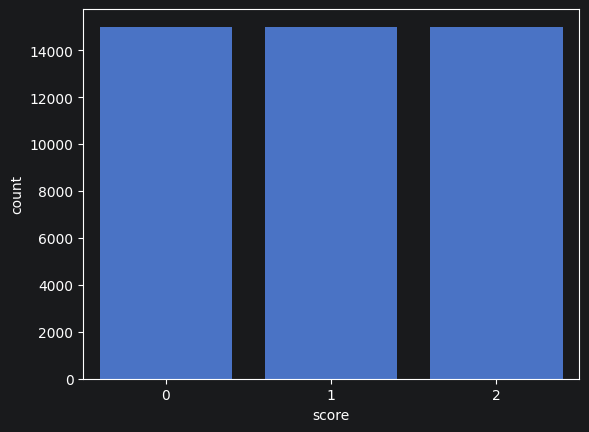

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot the score
sns.countplot(data = df , x="score")

this was imbalance dataset

In [236]:
# check the percentage
df.score.value_counts(normalize=True).mul(100).round(2)

score
2    33.33
0    33.33
1    33.33
Name: proportion, dtype: float64

In [237]:
df["word_count"] = df["review"].apply(lambda x: len(x.split()))
df.head(5)

,review,score,word_count
0,a fantastic course for any beginner. you'll ge...,2,63
1,the qwiklab assessments don't work and are a r...,0,142
2,i recommend this course to all beginners in un...,2,33
3,"if you are going to create a class, please dou...",0,68
4,"excelente curso, muy importante y til para apl...",2,15


In [238]:
df["word_count"].describe()

count    45000.000000
mean        37.382444
std         48.425092
min          1.000000
25%         11.000000
50%         22.000000
75%         45.000000
max       1349.000000
Name: word_count, dtype: float64

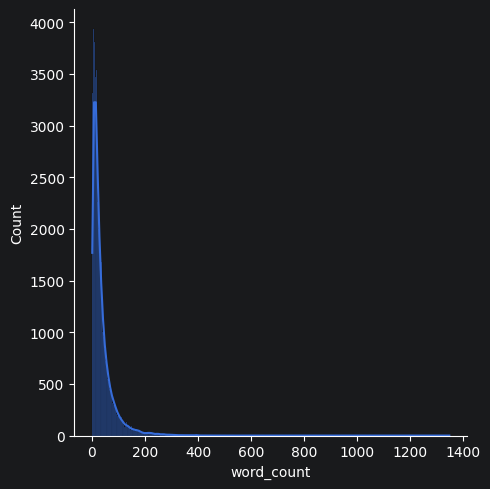

In [239]:
sns.displot(df["word_count"],kde=True)

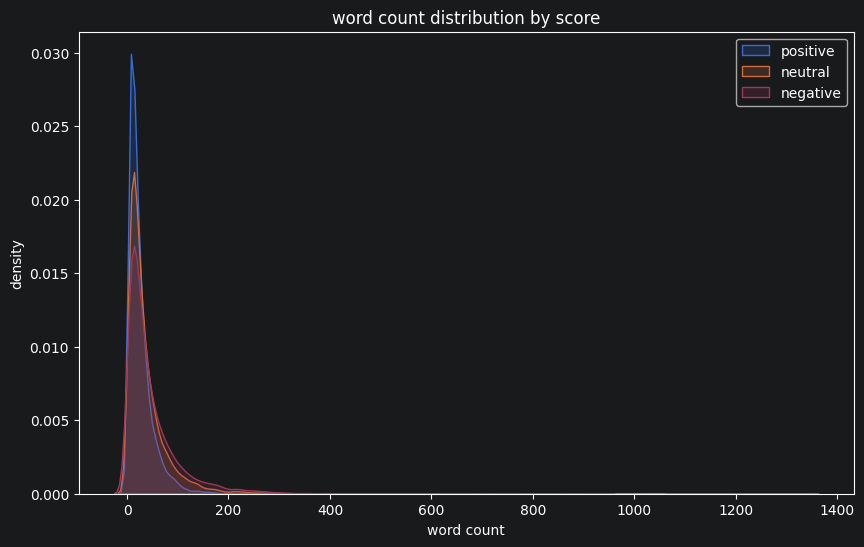

In [240]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df["score"]==2]["word_count"],label = "positive",fill=True,alpha = 0.2)
sns.kdeplot(df[df["score"]==1]["word_count"],label = "neutral",fill=True,alpha = 0.2)
sns.kdeplot(df[df["score"]==0]["word_count"],label = "negative",fill=True,alpha = 0.2)

plt.title("word count distribution by score")
plt.xlabel("word count")
plt.ylabel("density")
plt.legend()

plt.show()

<b>Positive comments (Scores 2):</b> The bar chart reveals these make up the vast majority of the dataset (especially score 5.0). However, the density plot shows a very sharp, high peak at a low word count for "high_positive." This indicates that while users leave positive feedback very frequently, they tend to keep it overwhelmingly brief and concise.

<b>Neutral comments (Score 1):</b> The bar chart shows these have a relatively low overall frequency. On the density plot, their word count distribution sits in the middle—lacking the extreme brevity of the positive reviews, but not quite as drawn-out as the negative ones.

<b>Negative comments (Scores 0):</b> While they make up a very small fraction of the total reviews, the density plot shows their curves have "fatter tails" and lower peaks compared to positive comments. This indicates that dissatisfied users are much more likely to write longer, detailed explanations to justify their low score.

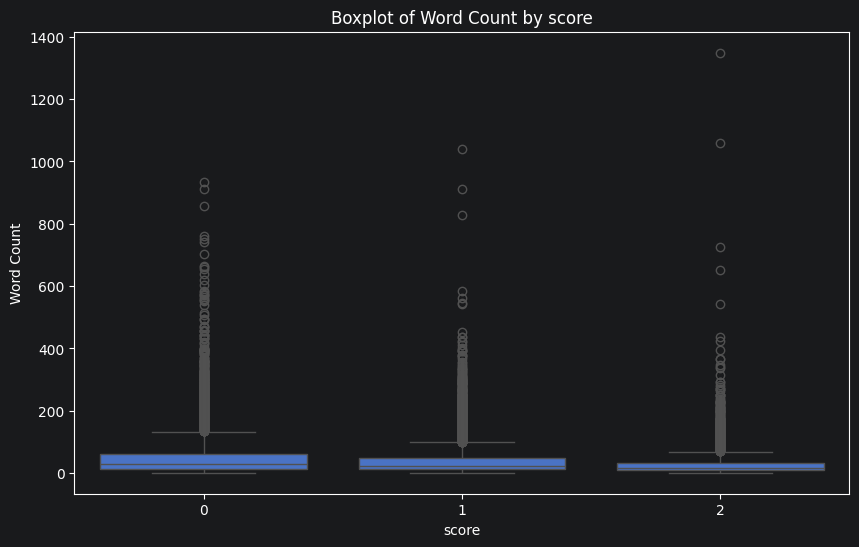

In [241]:
# create a boxplot for the 'wordcount' column categorized by 'score'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='score', y='word_count')
plt.title('Boxplot of Word Count by score')
plt.xlabel('score')
plt.ylabel('Word Count')
plt.show()

**Positive comments (Scores 2):** The median word count here is actually the lowest, with a very tight interquartile range (IQR, the colored box). This suggests that the vast majority of positive comments are quite brief. However, they do feature several extreme outliers reaching over 1,000 words.

**Neutral comments (Score 1):** The median word count and IQR sit squarely in the middle. They are generally shorter than negative reviews, but slightly longer and more varied in length than the bulk of the positive reviews.

**Negative comments (Scores 0):** These actually have the highest median word counts and the widest IQRs (especially score 2.0). This indicates that negative comments tend to be consistently more verbose and detailed across the board, even though their absolute highest outliers don't reach quite as far up the y-axis as the positive ones.

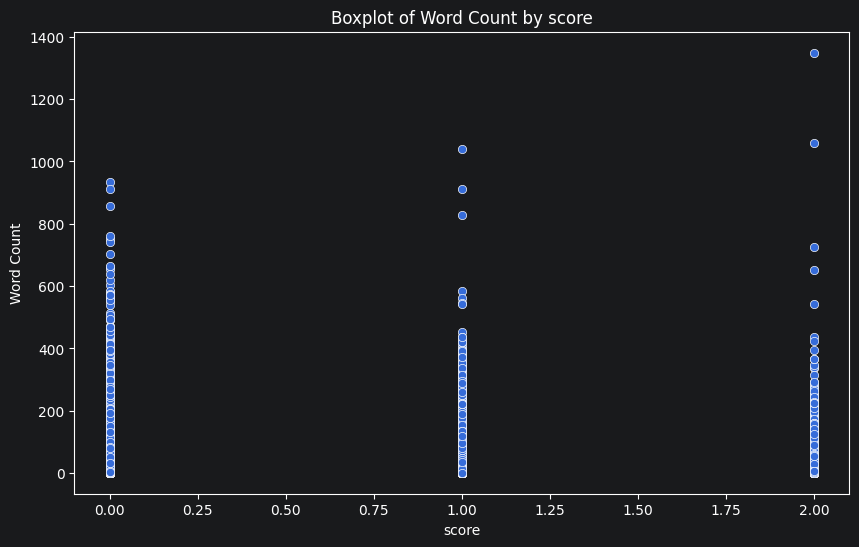

In [242]:
# create a boxplot for the 'wordcount' column categorized by 'score'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='score', y='word_count')
plt.title('Boxplot of Word Count by score')
plt.xlabel('score')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='score', ylabel='word_count'>

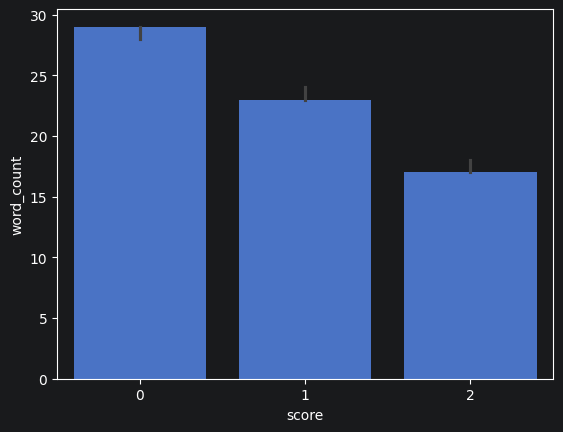

In [243]:
# median word counts among sentiments
sns.barplot(df,x='score',y='word_count',estimator='median')

<li>Seaborn’s error bars default to showing the uncertainty of your chosen estimator (the 95% confidence interval), not the min/max range of your raw data.
</li>
<li>Your scatterplot shows a massive, dense cluster of identical values at the very bottom for score 0.
</li>
<li>When Seaborn samples this data to calculate the median's confidence interval, almost every random sample yields that exact same bottom number.
</li>
<li>Because Seaborn is statistically certain the true median is that exact number, the error bar length is zero.</li>

In [244]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/breezy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [245]:
# English stopwords
stop_words = set(stopwords.words('english'))
# add teh english stop word column
df['num_stop_words'] = df['review'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [246]:
df.sample(5)

,review,score,word_count,num_stop_words
180,"very good learning course for beginners, it wi...",2,19,11
34224,"excellent explanations, especially considering...",2,10,3
43054,top course on coursera. this one is for all. b...,2,32,18
17759,an interesting overview of data science.,2,6,2
17915,this course does not allow us to answer the as...,1,22,10


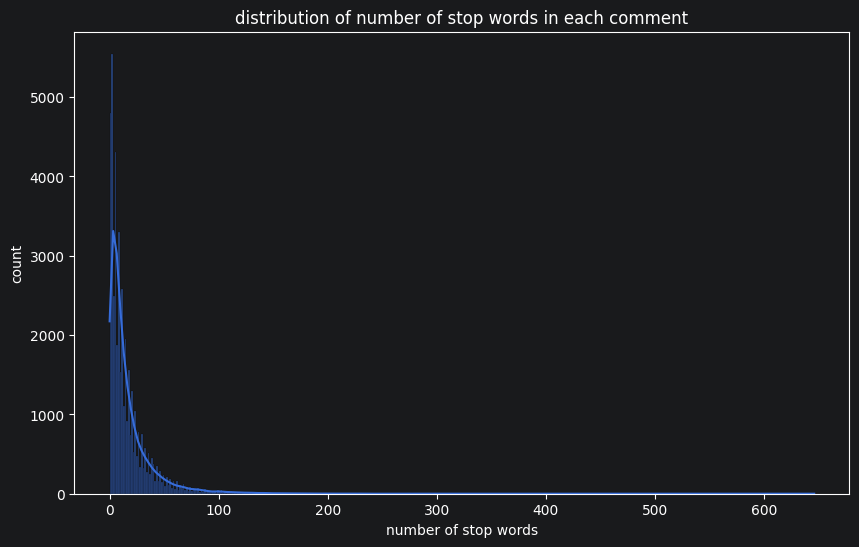

In [247]:
# create a distribution plot for view the "num_stop_words" column
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='num_stop_words',kde=True)
plt.title('distribution of number of stop words in each comment')
plt.xlabel('number of stop words')
plt.ylabel('count')
plt.show()

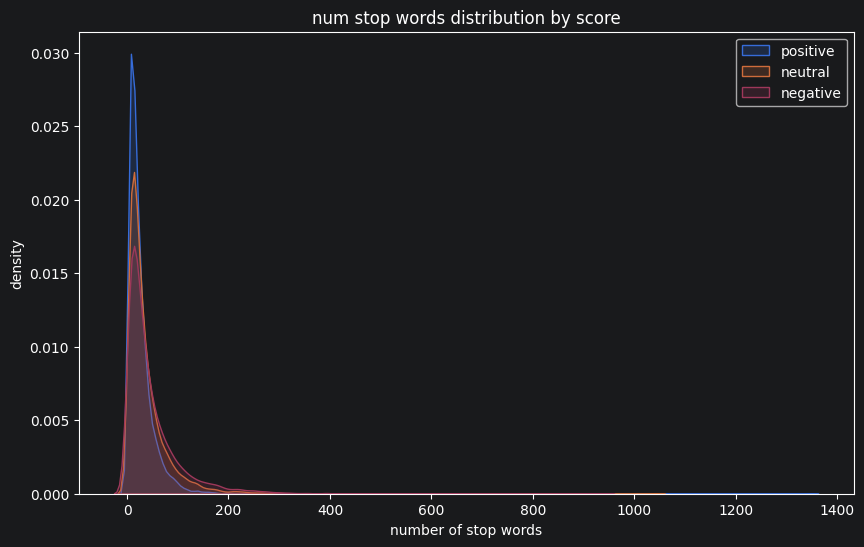

In [248]:
# create
plt.figure(figsize=(10,6))

sns.kdeplot(df[df["score"]==2]["word_count"],label = "positive",fill=True,alpha = 0.2)
sns.kdeplot(df[df["score"]==1]["word_count"],label = "neutral",fill=True,alpha = 0.2)
sns.kdeplot(df[df["score"]==0]["word_count"],label = "negative",fill=True,alpha = 0.2)
plt.title("num stop words distribution by score")
plt.xlabel("number of stop words")
plt.ylabel("density")
plt.legend()
plt.show()

<Axes: xlabel='score', ylabel='num_stop_words'>

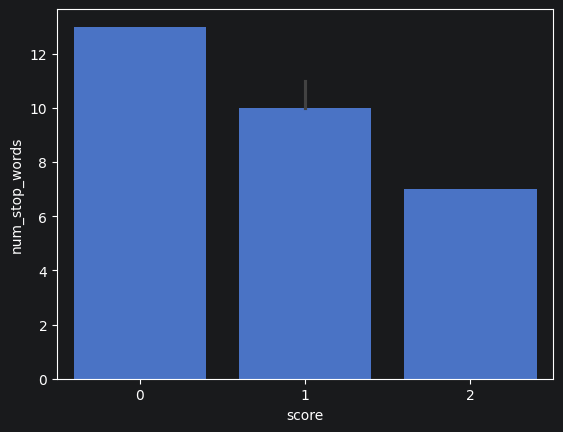

In [249]:
# check the median counts among the sentiments
sns.barplot(df,x='score',y='num_stop_words',estimator='median')

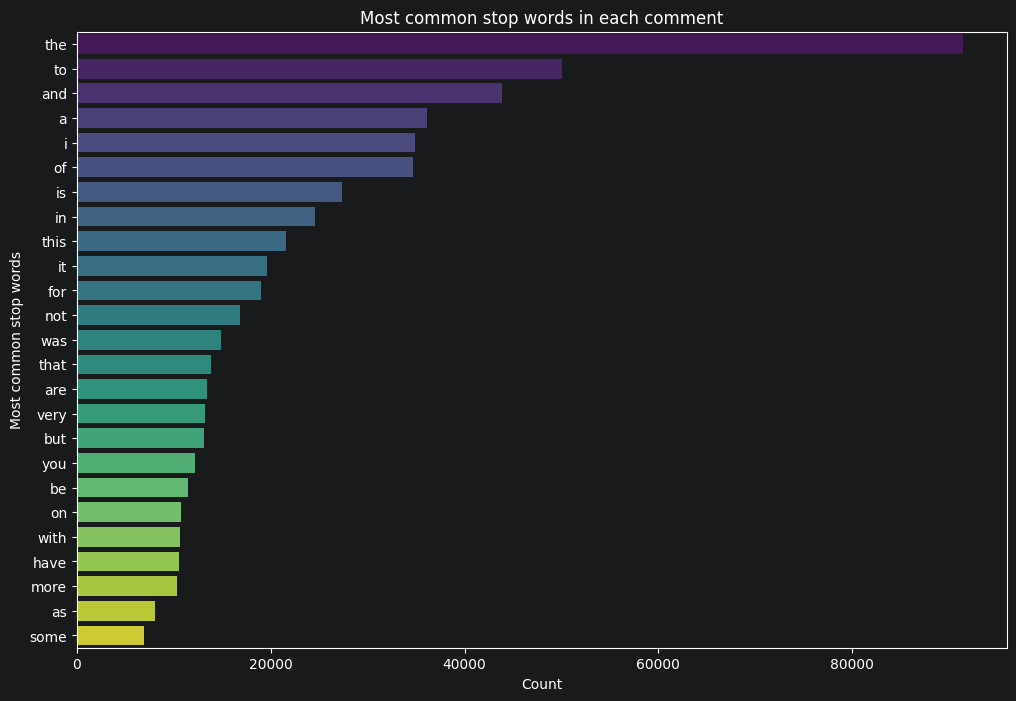

In [250]:
# Create a frequency distribution of stop words in the 'review' column
from collections import Counter

all_stop_words = [word for comment in df["review"] for word in comment.split() if word in stop_words]

most_common_stop_words = Counter(all_stop_words).most_common(25)
top_25_df = pd.DataFrame(most_common_stop_words, columns=['word','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df,x='count',y='word',palette='viridis',hue='word',legend=False)
plt.title('Most common stop words in each comment')
plt.ylabel('Most common stop words')
plt.xlabel('Count')
plt.show()

In [251]:
# add new column "num_chars" count of each char add to dataframe
df['num_chars'] = df['review'].apply(len)
df.head()

,review,score,word_count,num_stop_words,num_chars
0,a fantastic course for any beginner. you'll ge...,2,63,29,377
1,the qwiklab assessments don't work and are a r...,0,142,76,862
2,i recommend this course to all beginners in un...,2,33,14,199
3,"if you are going to create a class, please dou...",0,68,41,355
4,"excelente curso, muy importante y til para apl...",2,15,2,79


In [252]:
# check the character
df['num_chars'].describe()

count    45000.000000
mean       216.985289
std        280.887328
min          1.000000
25%         63.000000
50%        130.000000
75%        263.000000
max       7727.000000
Name: num_chars, dtype: float64

In [253]:
from collections import Counter

# combine all comments into one large string and count the total count of the char
all_text = ' '.join(df['review'])
char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)
char_frequency_df.tail()

,character,frequency
105,😀,1
112,🥰,1
111,💯,1
115,😘,1
116,😔,1


In [254]:
char_frequency_df

,character,frequency
1,,1682209
11,e,990845
4,t,740406
8,o,650232
0,a,583444
...,...,...
105,😀,1
112,🥰,1
111,💯,1
115,😘,1


In [255]:
# add new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['review'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,review,score,word_count,num_stop_words,num_chars,num_punctuation_chars
12453,"los contenidos tericos del curso, tanto las di...",1,61,8,380,8
5745,so many stuff are out of dates and some instru...,0,13,8,71,1
43638,i liked that the course was very assignment-or...,1,79,36,516,13
20691,overall this course was very shallow and only ...,0,58,28,346,3
12414,i expected more challenging questions...,1,5,2,40,3


In [256]:
df['num_punctuation_chars'].describe()

count    45000.000000
mean         5.023333
std          7.511523
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        321.000000
Name: num_punctuation_chars, dtype: float64

In [257]:
# create def extract the top 25 bigrams/trigram

def get_top_ngrams(corpus, ngram_rng = None ,n=25):
    vec = CountVectorizer(ngram_range=(ngram_rng,ngram_rng), stop_words='english')
    x = vec.fit_transform(corpus)
    sum_words = np.asarray(x.sum(axis=0)).flatten()
    words_freq = [
        (word, sum_words[idx])
        for word, idx in vec.vocabulary_.items()
    ]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return pd.DataFrame(words_freq[:n], columns=['ngram', 'count'])

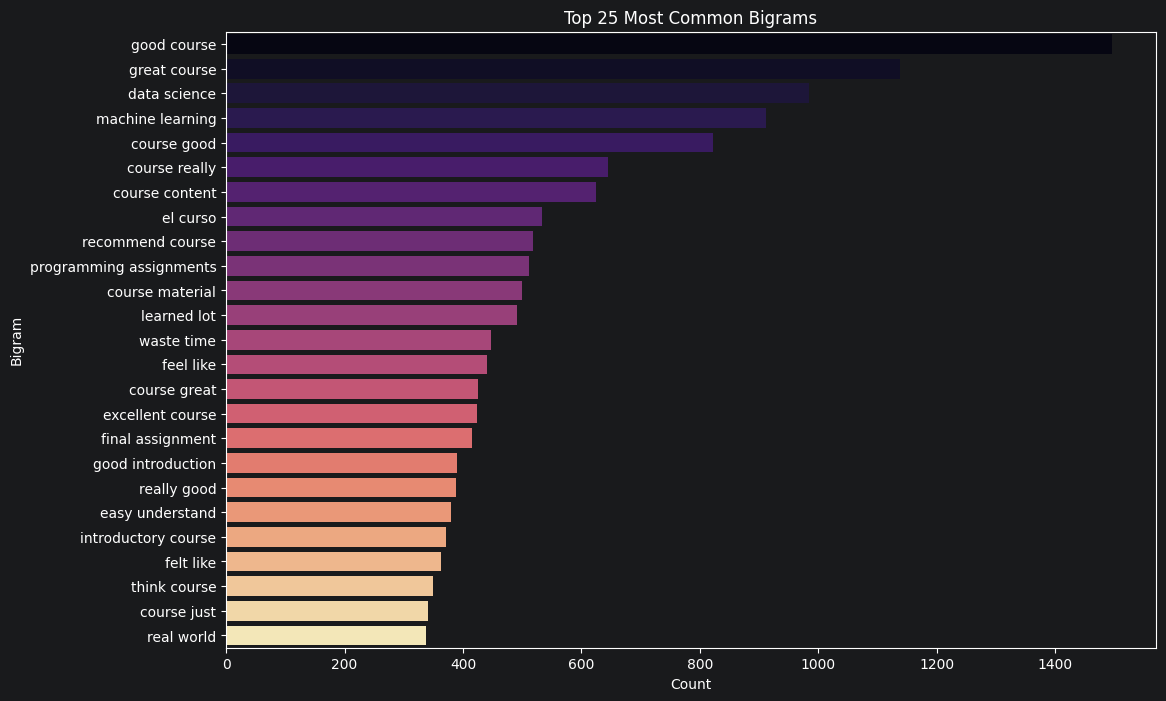

In [258]:
# the top 25 bigrams
top_25_bigrams_df = get_top_ngrams(df['review'], ngram_rng=2,n=25)

# plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='ngram', palette='magma',hue='ngram')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


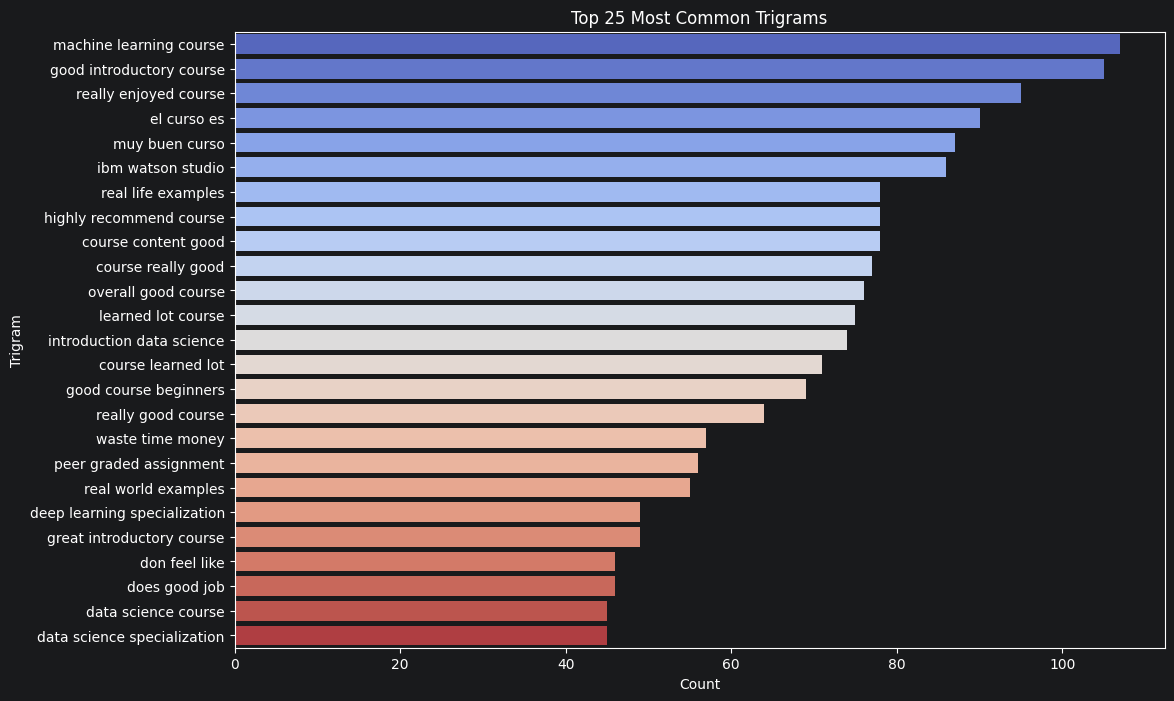

In [259]:
# the top 25 trigrams
top_25_trigrams_df = get_top_ngrams(df['review'], ngram_rng=3,n=25)

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='ngram', palette='coolwarm',hue='ngram')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [260]:
import regex as re


def filter_characters(text):
    if not isinstance(text, str):
        return text

    pattern = r'[^\x00-\x7F\p{Emoji}\p{Sc}]'

    # replace the unwanted characters with nothing (remove them)
    cleaned_text = re.sub(pattern, '', text)

    # clean up any extra spaces left behind by the removed characters
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

df['review'] = df['review'].apply(filter_characters)
df

,review,score,word_count,num_stop_words,num_chars,num_punctuation_chars
0,a fantastic course for any beginner. you'll ge...,2,63,29,377,5
1,the qwiklab assessments don't work and are a r...,0,142,76,862,24
2,i recommend this course to all beginners in un...,2,33,14,199,2
3,"if you are going to create a class, please dou...",0,68,41,355,6
4,"excelente curso, muy importante y til para apl...",2,15,2,79,1
...,...,...,...,...,...,...
44995,i have stopped taking some classes for this pa...,0,346,180,1934,43
44996,"i like it, thanks",2,4,1,17,1
44997,wonderful course!!! for every one!,2,5,1,34,4
44998,very bad explanations.,0,3,1,22,1


In [261]:
all_text = ' '.join(df['review'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
1,,1682209
11,e,990845
4,t,740406
8,o,650232
0,a,583444
...,...,...
105,😀,1
112,🥰,1
111,💯,1
115,😘,1


In [262]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [263]:
from nltk.corpus import stopwords

# Define the set of words you want to KEEP in your text (remove from stopwords)
negation_words = {
    'no', 'nor', 'not', 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'don', "don't", 'hadn', "hadn't",
    'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't",
    'wouldn', "wouldn't", 'but', 'against'
}

# Create the custom stopword set
without_neg_stopwords = set(stopwords.words('english')) - negation_words

# If you want it back as a list
custom_stopwords_list = list(without_neg_stopwords)
# Remove stop words from 'review' column, retaining essential ones
df['review_no_stopwords'] = df['review'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in without_neg_stopwords])
)

In [264]:
# lemmatize the wording
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# apply lemmatization to the 'review_no_stopwords' column
df['review_no_stopwords_lemmatized'] = df['review_no_stopwords'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /home/breezy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,score,word_count,num_stop_words,num_chars,num_punctuation_chars,review_no_stopwords,review_no_stopwords_lemmatized
0,a fantastic course for any beginner. you'll ge...,2,63,29,377,5,fantastic course beginner. get work excellent ...,fantastic course beginner. get work excellent ...
1,the qwiklab assessments don't work and are a r...,0,142,76,862,24,qwiklab assessments don't work requirement pas...,qwiklab assessment don't work requirement pas ...
2,i recommend this course to all beginners in un...,2,33,14,199,2,recommend course beginners understanding accou...,recommend course beginner understanding accoun...
3,"if you are going to create a class, please dou...",0,68,41,355,6,"going create class, please double check everyt...","going create class, please double check everyt..."
4,"excelente curso, muy importante y til para apl...",2,15,2,79,1,"excelente curso, muy importante til para aplic...","excelente curso, muy importante til para aplic..."


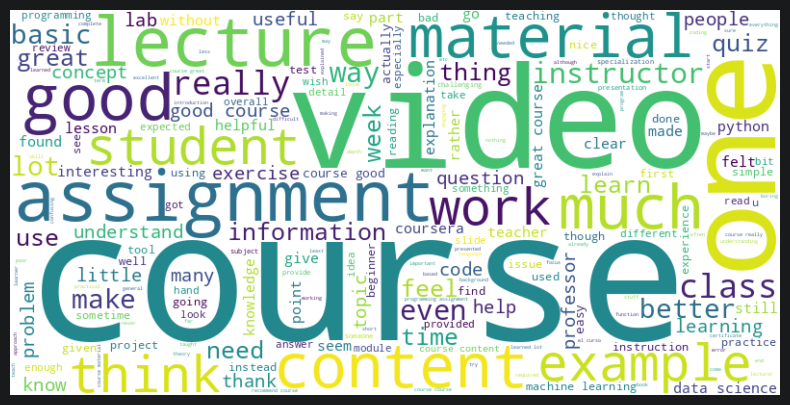

In [265]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['review_no_stopwords_lemmatized'])

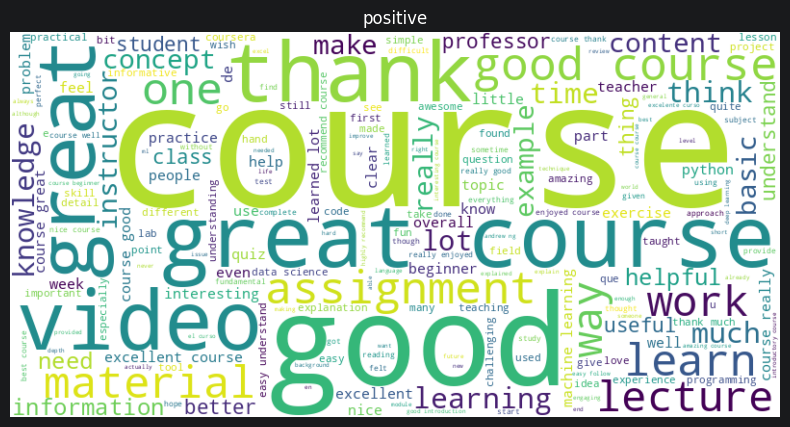

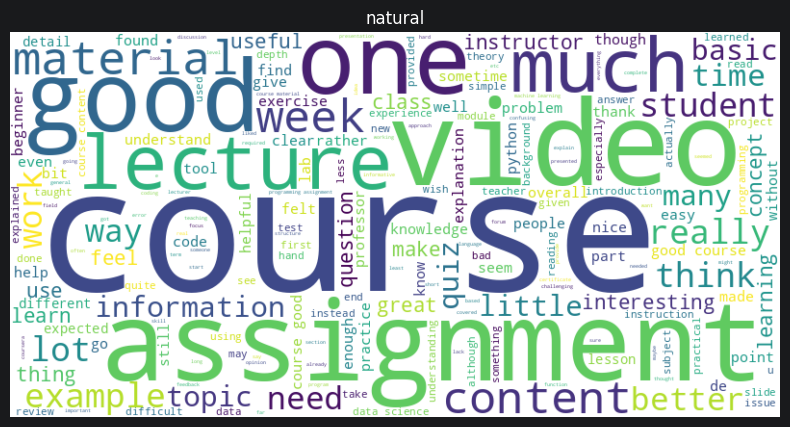

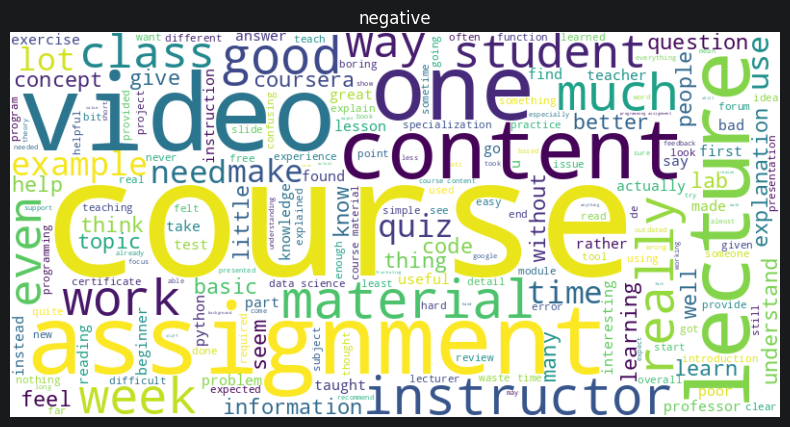

In [267]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text,title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()


plot_word_cloud(df[df['score'] == 2]['review_no_stopwords_lemmatized'],"positive")
plot_word_cloud(df[df['score'] == 1]['review_no_stopwords_lemmatized'],"natural")
plot_word_cloud(df[df['score'] == 0]['review_no_stopwords_lemmatized'],"negative")

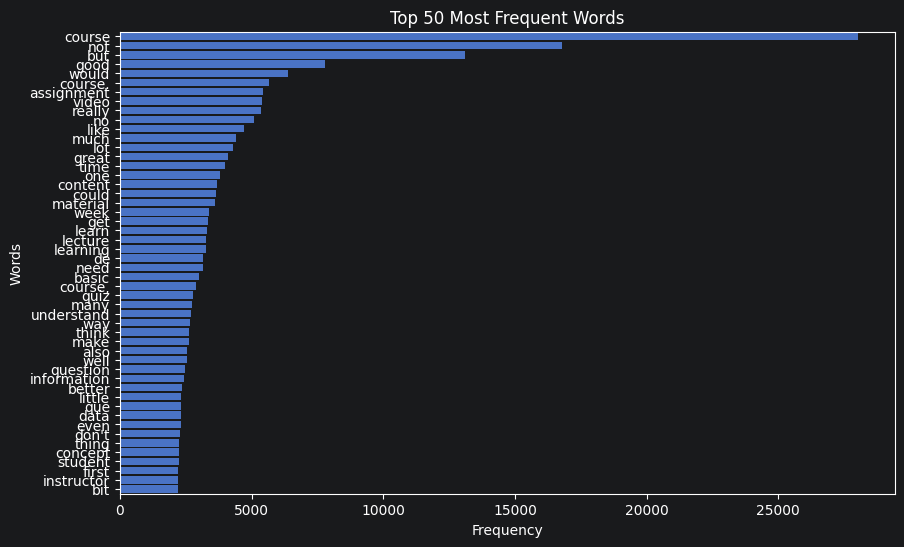

In [268]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # flatten all words in the content column
    words = ' '.join(df['review_no_stopwords_lemmatized']).split()

    counter = Counter(words)
    most_common_words = counter.most_common(n)


    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_top_n_words(df, n=50)


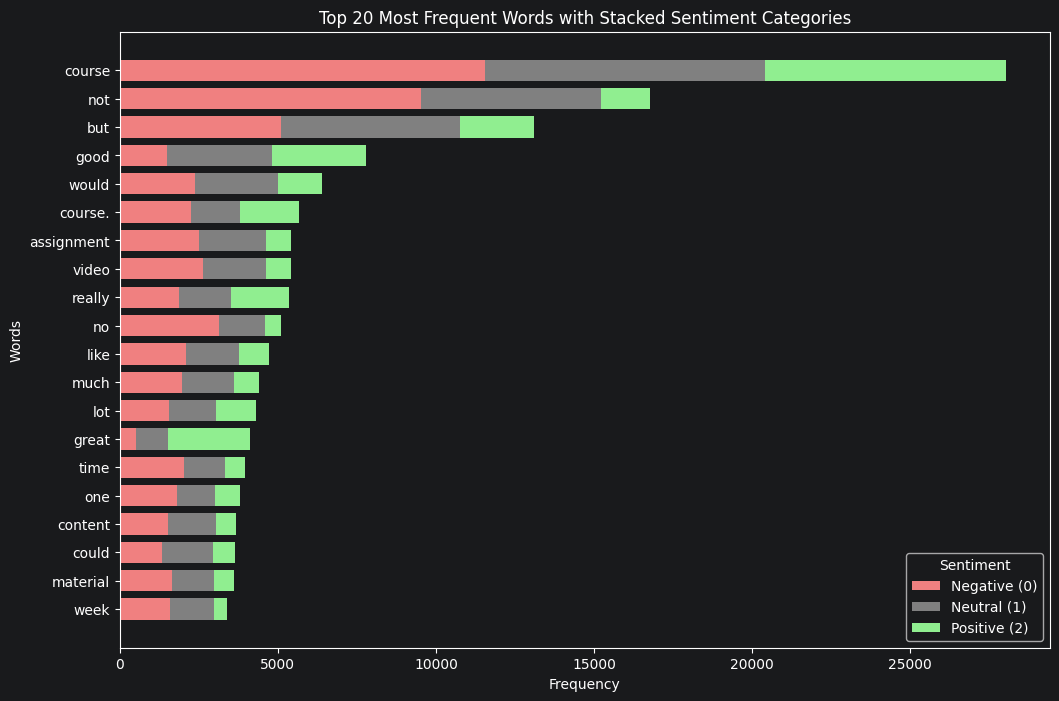

In [270]:
def plot_top_n_words_by_score(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment score."""
    word_score_counts = {}

    for idx, row in df.iterrows():
        if not isinstance(row['review_no_stopwords_lemmatized'], str):
            continue

        words = row['review_no_stopwords_lemmatized'].split()
        score = row['score']

        for word in words:
            if word not in word_score_counts:
                word_score_counts[word] = { 0: 0, 1: 0, 2: 0 }

            word_score_counts[word][score] += 1

    total_word_counts = {word: sum(counts.values()) for word, counts in word_score_counts.items()}
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    word_labels = top_words

    neg = [word_score_counts[word][0] for word in top_words]
    neu = [word_score_counts[word][1] for word in top_words]
    pos = [word_score_counts[word][2] for word in top_words]

    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    left_neu = neg
    left_pos = [i+j for i, j in zip(neg, neu)]


    plt.barh(word_labels, neg, color='lightcoral', label='Negative (0)', height=bar_width)
    plt.barh(word_labels, neu, left=left_neu, color='gray', label='Neutral (1)', height=bar_width)
    plt.barh(word_labels, pos, left=left_pos, color='lightgreen', label='Positive (2)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()
    plt.show()


plot_top_n_words_by_score(df, n=20)